# Fiber Segmentation Tutorial with SAM2

This tutorial demonstrates the segmentation and structural analysis of fiber cross-section micrographs using SAM2 — the Segment Anything Model v2 developed by Meta (Facebook) Research.
SAM2 leverages Vision Transformers (ViT) to achieve highly flexible, prompt-based instance segmentation.

The workflow begins with the Automatic Mask Generator, which segments individual fiber cross sections in a single micrograph.
Subsequently, the notebook introduces a path extraction routine that subdivides large panoramic images into smaller, overlapping patches for detailed and systematic analysis.

This step-by-step guide provides a practical introduction to automated fiber segmentation and quantitative microstructural characterization.

📝 **Notation**. In the following, **image** refers to the original grayscale or RGB input, **mask** denotes the binary segmentation map highlighting the foreground region, and instance designates the **labeled map** in which each distinct **object** or individual **mask** is assigned a unique integer identifier.


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/choROPeNt/segment-anything-2/blob/dev/notebooks/colab_analysis.ipynb)

## Environment Set-up
If running locally using jupyter, first install `SAM 2` in your environment using the installation instructions in the repository.

If running from Google Colab, set `using_colab=True` below and run the cell. In Colab, be sure to select 'GPU' under 'Edit'->'Notebook Settings'->'Hardware accelerator'. Note that it's recommended to use **A100 or L4 GPUs when running in Colab** (T4 GPUs might also work, but could be slow and might run out of memory in some cases).

In [1]:
using_colab = False # set to False if you are not working on Google Colab

### Load Packages

If you are on Google Colab some packages have to be installed that might take up to 5 min. Grab a a Coffe ☕️

❗️**THE FOLOWING CELL HAS TO BE EXECUTED TO LOAD ALL NECESSARY PACKAGES**❗️



In [2]:
if using_colab:
    import os
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import sys
    !{sys.executable} -m pip install opencv-python matplotlib
    # Install the custom repo from the dev branch
    !{sys.executable} -m pip install 'git+https://github.com/choROPeNt/segment-anything-2.git@dev'
    import matplotlib.pyplot as plt
    from PIL import Image
    import numpy as np
    from skimage.measure import regionprops_table, regionprops
    import pandas as pd
    from tqdm.auto import tqdm
    !mkdir -p ./images/
    !wget -P ./images/ https://raw.githubusercontent.com/choROPeNt/segment-anything-2/dev/images/test.tiff
    !mkdir -p ./checkpoints/
    !wget -P ./checkpoints/ https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_tiny.pt
else:
    import os
    # if using Apple MPS, fall back to CPU for unsupported ops
    os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1" # quite nice life hack
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import matplotlib.pyplot as plt
    from PIL import Image
    import numpy as np
    from skimage.measure import regionprops_table, regionprops
    import pandas as pd
    from tqdm.auto import tqdm

PyTorch version: 2.8.0
Torchvision version: 0.23.0
CUDA is available: False


## Device Selection

PyTorch currently supports the following hardware acceleration backends and are recommended:

- **CUDA** — NVIDIA GPU acceleration (Linux and Windows)
- **MPS** — Metal Performance Shaders for Apple Silicon (macOS)
- **ROCm** — AMD GPU acceleration (Linux)

Other backends such as **XPU** (Intel) or **TPU** (Google Cloud) require separate extensions and are not part of the core PyTorch package.

| Backend    | Platform    |  PyTorch support   |  Notes   |
| --- | --- | --- | --- |
| `CUDA `   |  Linux / Windows   |  ✅ Fully supported   |  Standard GPU backend for NVIDIA cards.   |   
| `MPS`    |   macOS (Apple Silicon or AMD GPUs)  |  ✅ Supported (since 1.12)   |  Uses Apple Metal; some ops may still fall back to CPU. Some numerical differences to `CUDA`  |     
|  `ROCm`   |   Linux (AMD GPUs)  |  ✅ Supported (since 1.10, stable ≥ 1.12)   |  Official ROCm builds available from PyTorch.org.   |     
|   `XPU / SYCL`  |  Intel GPUs   |  🧪 Experimental   |  Via Intel Extension for PyTorch (not in core).   |    
|  `TPU`   |  Cloud (Google Colab `TPU` VMs)   |  ❌ Not in core PyTorch   |   Requires torch_xla separately.  |    





























In [3]:
# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "\ngive numerically different outputs and sometimes degraded performance on MPS. "
        "\nSee e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

using device: mps

Support for MPS devices is preliminary. SAM 2 is trained with CUDA and might 
give numerically different outputs and sometimes degraded performance on MPS. 
See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion.


# Part 1: Single Image Analysis

## Load Image

**Note**:
SAM2 expects input images with the shape `[W, H, 3]`, where the last dimension corresponds to the RGB color channels.
If your image is grayscale, convert it to RGB by duplicating the single channel across all three channels.

The model accepts both 8-bit and 16-bit integer images. During preprocessing, SAM2 automatically converts the input to floating-point format and normalizes pixel values to the range [0, 1].

Images larger than 1024 × 1024 pixels `[W, H]` are automatically downscaled while preserving their aspect ratio. The resulting segmentation masks are then upsampled back to the original image resolution.

You can upload your own image using the file navigator on the left 📁. Uploaded files are stored in your Google Drive under content/images (content is the default working directory).
If you are working locally, the default working directory is the folder containing this notebook.

Please change the `file_path` variable accordingly 🚀

In [5]:
file_path = "../images/test.tiff"

image = Image.open(file_path)

if image.mode in ("L", "I"):  # grayscale
    image = image.convert("RGB")
elif image.mode == "RGBA":    # drop alpha
    image = image.convert("RGB")

image_np = np.array(image) # convert the image to an numpy array
print(f"Image has the shape: W {image_np.shape[0]}, H {image_np.shape[1]} and datatype {image_np.dtype}")

Image has the shape: W 728, H 1630 and datatype uint8


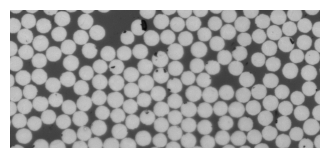

In [6]:
## Show the Image
plt.figure(figsize=(4, 4))
plt.imshow(image_np)
plt.axis('off')
plt.show()

**Optional**: Center crop the image to match the input size

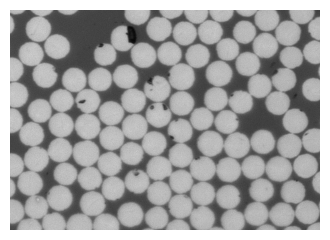

In [7]:
## center crop the image
def center_crop_np(image: np.ndarray, crop_size=1024):
    """Fast center crop for a NumPy image.

    Args:
        image (np.ndarray): Input image as a NumPy array (H, W) or (H, W, C).
        crop_size (int): Target crop size (assumes square crop).

    Returns:
        np.ndarray: Center-cropped image.
    """
    h, w = image.shape[:2]  # Get height and width
    ch, cw = crop_size, crop_size  # Crop size

    # Compute center crop coordinates
    start_h = max((h - ch) // 2, 0)
    start_w = max((w - cw) // 2, 0)
    end_h = min(start_h + ch, h)
    end_w = min(start_w + cw, w)

    return image[start_h:end_h, start_w:end_w]


image_np = center_crop_np(image_np)
## Show the Image
plt.figure(figsize=(4, 4))
plt.imshow(image_np)
plt.axis('off')
plt.show()

## Automatic mask generation
To run automatic mask generation, provide a version of SAM 2 to the `SAM2AutomaticMaskGenerator` class. Set the path below to the SAM 2 checkpoint.

In [9]:
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator
from sam2.addons import show_anns

# set here your checkpoint path and path to yourmodel cfg
sam2_checkpoint = "../checkpoints/sam2.1_hiera_tiny.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_t.yaml"

sam2 = build_sam2(model_cfg, sam2_checkpoint, device=device, apply_postprocessing=False)

mask_generator = SAM2AutomaticMaskGenerator(
    model=sam2,                 # The preloaded SAM2 model used for automatic segmentation

    points_per_side=48,         # Sampling density of prompt points per image side.
                                # A higher value → more points → denser coverage, better for small or fine structures,
                                # but also slower and more memory-intensive.

    points_per_batch=64,        # Number of sampled points processed simultaneously by the model.
                                # Controls batch size; balance between speed and GPU memory usage.

    pred_iou_thresh=0.1,        # Minimum predicted IoU between the mask and its region proposal
                                # required to keep a candidate. Lower this to retain weaker (small or uncertain) masks.

    min_mask_region_area=50,    # Minimum area (in pixels) for a mask to be kept.
                                # Increasing this removes tiny specks; decreasing it helps keep very small objects.

    box_nms_thresh=0.1,         # Non-Maximum Suppression (NMS) threshold for filtering overlapping boxes.
                                # Lower values make the filter stricter, keeping fewer overlapping regions.

    stability_score_thresh=0.9  # Confidence threshold measuring mask consistency under perturbations.
                                # Lowering this (e.g. 0.7–0.8) retains more masks, especially smaller or noisier ones.
)

To generate masks, simply call the generate function on an input image.

The resulting variable, masks, is a sequence of dictionaries, where each dictionary represents one detected region (fiber cross-section) and contains the following entries:
- `segmentation` : binary mask of the segmented region
- `area` : pixel area of the mask
- `bbox` : bounding box coordinates in the format `[x, y, width, height]`
- `predicted_iou` : model’s confidence estimate of segmentation accuracy (Intersection-over-Union (Jaccard) score)
- `point_coords` : coordinates of the prompt points used (if any)
- `stability_score` : measure of segmentation consistency under perturbations
- `crop_box` : image region from which the mask was generated

This output provides both the segmentation itself and useful metadata for filtering, analysis, or visualization.

In [10]:
print(f"Detection started...")
masks = mask_generator.generate(image_np)
print(f"Detection finished...")
print(f"Detected objects: {len(masks)}")

Detection started...


/Users/christian/Projects/segment-anything-2/sam2/sam2_image_predictor.py:431: UserWarning: cannot import name '_C' from 'sam2' (/Users/christian/Projects/segment-anything-2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  masks = self._transforms.postprocess_masks(


Detection finished...
Detected objects: 120


In [11]:
# Sort masks by area (largest first)
sorted_masks = sorted(masks, key=lambda m: m["area"], reverse=True)

# Remove the largest mask if it is likely background (area > 1e5 px)
if sorted_masks and sorted_masks[0]["area"] > 1e5:
    sorted_masks = sorted_masks[1:]

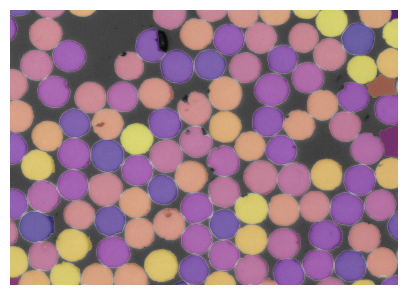

In [12]:
# Display some results
plt.figure(figsize=(5, 5))
plt.imshow(image_np)
label_canvas = show_anns(sorted_masks)
plt.axis('off')
plt.show()

## Statistics

Using the `label_map`, we can now extract quantitative information about the segmented fiber cross sections.
For this purpose, we apply the function `regionprops` (`regionprops_table` returns a pandas dataframe) from the `scikit-image` package, which computes a wide range of morphological and intensity-based statistics for each labeled region (comparable to 1D-descriptors).

Typical properties include:
- Area: number of pixels belonging to each fiber
- Centroid: spatial position of the fiber center
- Equivalent diameter: diameter of a circle with the same area as the fiber
- Eccentricity: measure of how elongated the fiber cross section is
- Orientation: local rotation of the fitted ellipse

These descriptors enable detailed quantitative analysis of fiber size, shape, and spatial distribution within the micrograph.

In [13]:
def masks_to_labelmap(masks, image_shape):
    """
    Convert a list of SAM2 mask dictionaries to a label map.

    Parameters
    ----------
    masks : list of dict
        Each dictionary must contain a boolean array under the key 'segmentation'.
    image_shape : tuple
        Shape of the target label map (height, width).

    Returns
    -------
    label_map : np.ndarray, dtype=int16
        Label map where each segmented region is assigned a unique integer ID.
    """
    label_map = np.zeros(image_shape, dtype=np.int16)

    for i, mask_dict in enumerate(masks, start=1):
        mask = mask_dict["segmentation"]
        label_map[mask] = i

    return label_map

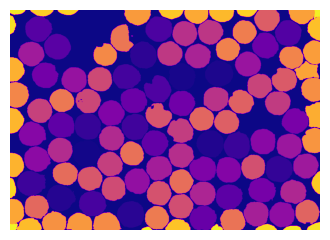

In [14]:
image_shape = image_np.shape[:2]

label_map = masks_to_labelmap(sorted_masks,image_shape)

# Display some results
plt.figure(figsize=(4, 4))
plt.imshow(label_map,cmap="plasma")
plt.axis('off')
plt.show()

In [15]:
# Compute region properties from the label map
result_dict = regionprops_table(
    label_map,
    properties=(
        "label",
        "area",
        "bbox",
        "centroid",
        "convex_area",
        "eccentricity",
        "equivalent_diameter",
        "extent",
        "feret_diameter_max",
        "filled_area",
        "major_axis_length",
        "minor_axis_length",
        "orientation",
        "perimeter",
        "solidity",
        "moments_hu",
    ),
)

# Convert to DataFrame for easier analysis
props_df = pd.DataFrame(result_dict)

# Display summary
print(f"Extracted {len(props_df)} fiber regions.")
props_df.head()



Extracted 120 fiber regions.


,label,area,bbox-0,bbox-1,bbox-2,bbox-3,centroid-0,centroid-1,convex_area,eccentricity,...,orientation,perimeter,solidity,moments_hu-0,moments_hu-1,moments_hu-2,moments_hu-3,moments_hu-4,moments_hu-5,moments_hu-6
0,1,6259.0,432,209,520,299,474.843585,251.588433,6358.0,0.218507,...,-1.280659,295.178716,0.984429,0.159676,0.000015,0.000026,8.713807e-09,-2.846152e-15,-3.246477e-11,2.977378e-15
1,2,6218.0,178,525,267,613,222.989546,567.607913,6355.0,0.245649,...,0.550906,300.249783,0.978442,0.159630,0.000025,0.000004,1.461821e-08,1.305016e-15,4.084060e-11,-3.124675e-15
2,3,6214.0,169,644,256,738,212.419054,690.536209,6340.0,0.389588,...,-1.489441,296.492424,0.980126,0.159868,0.000172,0.000003,1.088312e-09,-6.002548e-17,-1.407139e-11,-1.389692e-17
3,4,6203.0,400,616,489,705,443.382718,661.576173,6311.0,0.218137,...,0.828624,296.249783,0.982887,0.159582,0.000015,0.000026,1.769206e-08,6.008845e-15,7.032785e-12,1.044128e-14
4,5,6133.0,580,121,666,218,622.115767,166.645198,6338.0,0.393268,...,1.384230,308.391919,0.967655,0.160707,0.000181,0.000061,3.054277e-07,9.931179e-13,1.871224e-09,-8.602146e-13


In [16]:
props_df.to_csv("results.csv",index=False)

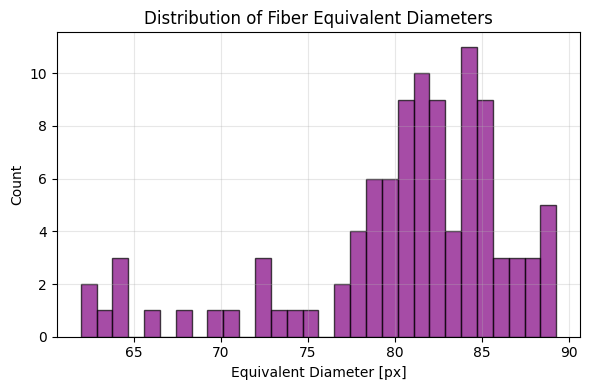

In [17]:
# Extract equivalent diameters from the DataFrame
equiv_diameters = props_df["equivalent_diameter"][props_df["area"] > 3000]

# Plot histogram
plt.figure(figsize=(6, 4))
plt.hist(equiv_diameters, bins=30, facecolor="purple",edgecolor="black", alpha=0.7)

plt.title("Distribution of Fiber Equivalent Diameters")
plt.xlabel("Equivalent Diameter [px]")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Higher-Order Descriptor ($S_2$)

The two-point correlation function $S_2$ is a higher-order statistical descriptor that captures spatial relationships within a microstructure. Instead of relying solely on volume fractions or simple geometric metrics, $S_2(r)$ measures how phase information (e.g., fiber vs. matrix) correlates as a function of distance r. This allows us to quantify clustering, characteristic length scales, anisotropy, and overall spatial order in the material.

### FFT-based computation

In practice, $S_2$ is computed using FFT-based convolution, which makes the correlation estimation fast and efficient even for large images.
For a binary phase indicator function $I(\mathbf{x})$, the descriptor is evaluated via:

$$S_2(\mathbf{r}) = \mathcal{F}^{-1}\left( \mathcal{F}(I)\,\cdot\,\mathcal{F}(I)^{*} \right)$$

where \mathcal{F} is the Fast Fourier Transform and \overline{\mathcal{F}(I)} is its complex conjugate.
This approach guarantees correct correlation estimation while keeping the computation cost extremely low.

What the variables represent
- Binary map:
$I(\mathbf{x}) \in \{0, 1\} $ — the phase indicator map (1 = phase of interest, 0 = background).
This is the input to the FFT-based computation.
- $S_2(x, y)$
The full 2D FFT-based correlation map.
Each pixel gives the probability that two points separated by vector $(x,y)$ belong to the same phase.
- $S_2(r)$
The radial average of the 2D map, where correlation is averaged over all directions with the same radius $r$.
Produces a 1D curve describing how spatial similarity decays with distance.

What $S_2$ provides

The descriptor reveals:
	•	Clustering intensity and scale
	•	Characteristic correlation length
	•	Presence of periodicity or directional features
	•	Typical microstructure size scale
	•	Degree of spatial randomness vs. spatial order

Because of its FFT-based formulation, $S_2$ is ideal for large micrographs and widely used in materials science for microstructure characterization, RVE selection, and structure–property modeling.


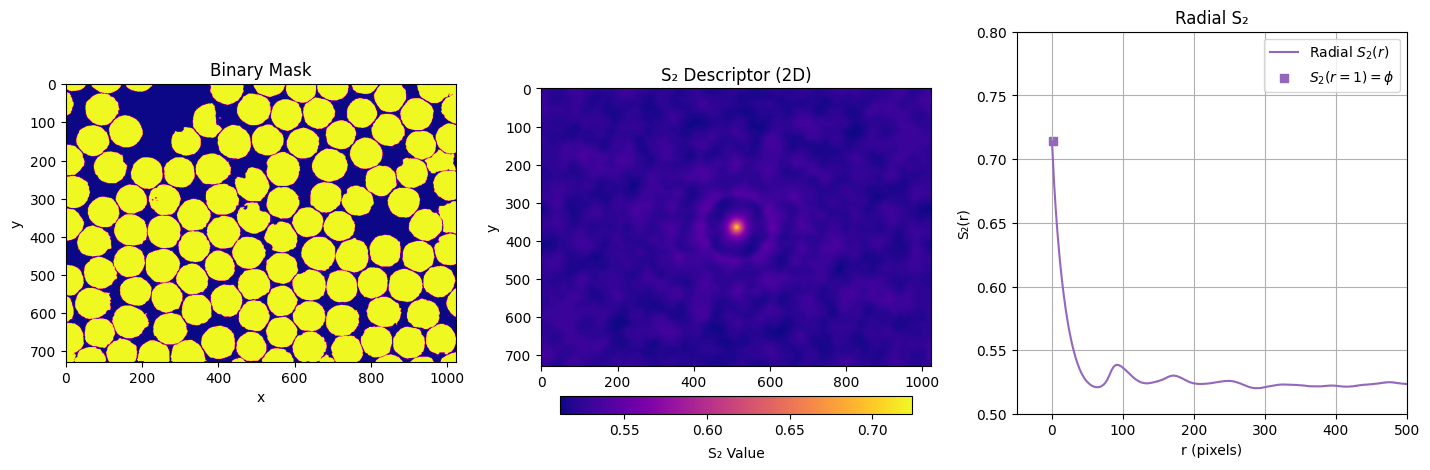

In [46]:
from sam2.addons import s2_descriptor

# Convert label map to binary (1 = foreground, 0 = background)
binary_map = torch.tensor((label_map > 0), dtype=torch.long).unsqueeze(0)

# Compute S2 and radial S2
s2, s2r = s2_descriptor(binary_map, radial=True)

# Move data to NumPy for plotting
binary_np = binary_map.squeeze(0).cpu().numpy()
s2_np = s2.squeeze(0).cpu().numpy()
s2r_np = s2r.squeeze().cpu().numpy()

# Plot
fig, axs = plt.subplots(1, 3, figsize=(14.4, 4.8))

# --- Binary map ---
axs[0].imshow(binary_np, cmap="plasma")
axs[0].set_title("Binary Mask")
axs[0].set_xlabel(r"x")
axs[0].set_ylabel(r"y")

# --- S2 2D map ---
im1 = axs[1].imshow(s2_np, cmap="plasma")
axs[1].set_title("S₂ Descriptor (2D)")
axs[1].set_xlabel(r"x")
axs[1].set_ylabel(r"y")
# horizontal colorbar below the image
cbar1 = fig.colorbar(
    im1,
    ax=axs[1],
    orientation="horizontal",
    fraction=0.046,   # size of the bar relative to the axis
    pad=0.08          # spacing between image and colorbar
)
cbar1.set_label("S₂ Value", labelpad=6)

# --- Radial S2 ---
axs[2].plot(s2r_np[1:], color="tab:purple", label="Radial $S_2(r)$")
axs[2].scatter(1, s2r_np[1], marker="s", color="tab:purple", label=r"$S_2(r=1)=\phi$")

axs[2].set_xlim(-50, 500)
axs[2].set_ylim(0.5, 0.8)
axs[2].set_title("Radial S₂")
axs[2].set_xlabel("r (pixels)")
axs[2].set_ylabel("S₂(r)")
axs[2].grid(True)
axs[2].legend(loc="best")

plt.tight_layout()
plt.show()

# Part 2: Patch Analysis

## Load Image
In this section, we use the same input micrograph but subdivide it into multiple overlapping patches of size 1024 × 1024 pixels.
This patch-based approach enables efficient processing of large images that exceed GPU memory limits and allows for localized analysis of fiber size, shape, and distribution across different regions of the microstructure.

In [15]:
file_path = "./images/test.tiff"

image = Image.open(file_path)

if image.mode in ("L", "I"):  # grayscale
    image = image.convert("RGB")
elif image.mode == "RGBA":    # drop alpha
    image = image.convert("RGB")

image_np = np.array(image)
print(f"Image has the shape {image_np.shape} and datatype {image_np.dtype}")

Image has the shape (728, 1630, 3) and datatype uint8


## Tile the Image

In [16]:
from sam2.addons import Sam2Patcher

 ## intialize tiler
patcher = Sam2Patcher(
    patch_h=1024,
    patch_w=1024,
    overlap_h=512,
    overlap_w=512,
    pad_mode="constant",
    merge_iou=0.1
)

In [17]:
## Patching
patches, offsets, padded_shape = patcher.tile_numpy(image_np)
print(f"Tiled into {len(patches)} patches of shape {patches[0].shape}, \
      padded shape: {padded_shape}")

Tiled into 3 patches of shape (728, 1024, 3),       padded shape: (728, 1630, 3)


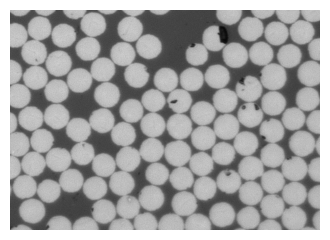

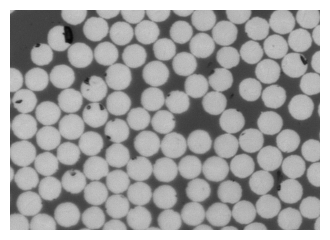

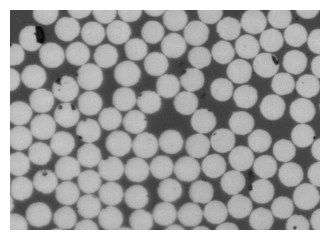

In [18]:
for i in range(min(4,len(patches))):
  plt.figure(figsize=(4,4))
  plt.imshow(patches[i])
  plt.axis("off")
  plt.show()

## Automatic Mask Generation per Patch

Loop over all patches and generate segmentation masks for the detected objects.
All results are collected into a sequence of lists of dictionaries, where each dictionary contains the segmentation data and associated metadata for one object.

In [19]:
#----- Mask Generation -----
all_detections = []
for p in tqdm(patches,
    total=len(patches),
    desc="Mask generation",
    unit="patch"
):
    ## detect masks per patch
    detections = mask_generator.generate(p)
    ## gather results
    all_detections.append(detections)

Mask generation:   0%|          | 0/3 [00:00<?, ?patch/s]

display some results

In [ ]:
for i in range(min(4,len(patches))):
  plt.figure(figsize=(4,4))
  plt.imshow(patches[i])
  show_anns(all_detections[i])
  plt.axis("off")
  plt.show()

## Stitching the Results

After processing all patches, the individual results are gathered and stitched back together to reconstruct the segmentation of the original image.

**Note**:
Each entry in the resulting instances list is a dictionary containing the following fields:
- `"id"` — integer identifier corresponding to the label value in the `label_map`
- `"area"` — pixel area of the segmented region
- `"segmentation_crop"` — cropped segmentation mask (restricted to the bounding box to reduce data size)
- `"bbox"` — bounding box of the segmentation in the format `[x0, y0, w, h]`

In [ ]:
label_map, instances = patcher.stitch_sam2_instances(
    padded_shape_hw=padded_shape[:2],
    offsets=offsets,
    per_tile_sam2=all_detections,
    debug=False,
)

In [ ]:
# Optional: filter the instances by area and delete the biggest "background"
# SAM2 some times detects the background as object
instances_sorted = sorted(instances, key=lambda x: x["area"])


In [ ]:
  plt.figure(figsize=(4,4))
  plt.imshow(image_np)
  show_anns(instances_sorted[:-1])
  plt.axis("off")
  plt.show()

## Save the Results
You can save the results from the `label_map` as `*.tiff` iamge e.g. to load it in Fiji as a labelmap. Refining the labels is managable via Labelkit.manageable via Labelkit.

In [ ]:
Image.fromarray(label_map).save("results.tiff")

for very large files and panoramas it is recommended to safe the results as a `*.hdf5` container.

In [ ]:
from sam2.addons import write_h5
dict_out = {
    "image": image_np ,
    "labels": label_map,
    "instances": instances
}

write_h5(path = "results.h5", dict_out= dict_out)